# Fairness: Group vs. Individual Notions

"Is this model fair?" is not a yes/no question until you specify *which*
fairness definition you mean — and several of the most natural definitions
are mathematically incompatible with each other. This tutorial builds up
the two major families of fairness definitions used in practice:

- **Group fairness** — statistical parity across protected groups (e.g. race,
  sex). Definitions here include demographic parity, equalized odds, equal
  opportunity, and predictive parity.
- **Individual fairness** — "similar individuals should receive similar
  outcomes," a definition that operates at the level of individuals rather
  than group aggregates.

We'll formally define each, prove why you generally *cannot* satisfy several
of the group definitions simultaneously when base rates differ across
groups, and measure all of them on the real ProPublica COMPAS recidivism
dataset — the same dataset at the center of the 2016 "Machine Bias"
investigation that kicked off much of the modern algorithmic fairness field.

By the end you'll be able to compute each fairness metric on a real model,
explain in one sentence what tradeoff each one encodes, and argue for which
definition fits a given real-world deployment — and which doesn't.

## 1. Theory

### 1.1 Setup and notation

Let:
- $X$ be the feature vector for an individual,
- $A \in \{0, 1\}$ be a binary protected attribute (e.g. race, sex) — we'll
  use binary for clarity; the definitions generalize to multi-valued $A$,
- $Y \in \{0, 1\}$ be the true outcome label,
- $\hat{Y} \in \{0, 1\}$ be the model's predicted outcome (from a thresholded
  score $R \in [0,1]$, i.e. $\hat{Y} = \mathbb{1}[R \ge t]$).

In our running example (COMPAS), $Y=1$ means "actually reoffended within
two years," $\hat{Y}=1$ means "model/COMPAS flagged as high risk," and $A$
is race (Black vs. White defendants, the comparison the original ProPublica
analysis focused on).

### 1.2 Group fairness definitions

**Demographic parity (statistical parity).** The prediction is independent
of the protected attribute:

$$P(\hat{Y}=1 \mid A=0) = P(\hat{Y}=1 \mid A=1)$$

In words: both groups get flagged at the same *rate*, regardless of whether
they actually reoffend at the same rate. The **demographic parity
difference** is the gap between these two probabilities; a value of 0 is
perfect parity.

**Equalized odds** (Hardt, Price, Srebro 2016). The prediction is
independent of the protected attribute *conditional on the true outcome*:

$$P(\hat{Y}=1 \mid A=0, Y=y) = P(\hat{Y}=1 \mid A=1, Y=y) \quad \forall y \in \{0,1\}$$

This requires *both* the true positive rate (TPR, i.e. recall) *and* the
false positive rate (FPR) to match across groups. Equivalently: among people
who actually will reoffend, both groups are flagged at the same rate; among
people who won't, both groups are flagged at the same rate.

**Equal opportunity** is the one-sided relaxation of equalized odds —
only the TPR needs to match:

$$P(\hat{Y}=1 \mid A=0, Y=1) = P(\hat{Y}=1 \mid A=1, Y=1)$$

This says: among people who will actually reoffend, both groups get
flagged (i.e. correctly identified) at equal rates. It ignores the FPR gap.

**Predictive parity (calibration within groups).** The *outcome given the
prediction* is independent of the protected attribute:

$$P(Y=1 \mid \hat{Y}=1, A=0) = P(Y=1 \mid \hat{Y}=1, A=1)$$

In words: among people flagged high-risk, the actual reoffense rate is the
same across groups — a "high risk" score means the same thing regardless of
race. This is the definition COMPAS's vendor (Northpointe/Equivant) argued
their tool satisfied, in response to ProPublica's critique.

### 1.3 The impossibility result

Here is the central, uncomfortable fact of this field. Define the group
**base rate** $p_a = P(Y=1 \mid A=a)$ — the true prevalence of the outcome
in group $a$. Chouldechova (2017) and, independently, Kleinberg, Mullainathan
& Raghavan (2016) proved:

> If the base rates differ between groups ($p_0 \ne p_1$), then no
> classifier — regardless of how it's trained — can simultaneously satisfy
> **predictive parity** and **equalized odds** (specifically, equal false
> positive rates), except in the trivial case of a perfect classifier
> ($Y = \hat{Y}$ always).

**Sketch of why.** Fix a group $a$. Using Bayes' rule, its false positive
rate and its "precision" (predictive parity's positive predictive value,
PPV) are related through the base rate $p_a$:

$$\text{FPR}_a = \frac{p_a}{1-p_a} \cdot \frac{1 - \text{PPV}_a}{\text{PPV}_a} \cdot (1 - \text{FNR}_a)$$

This identity (derivable directly from the definitions of FPR, PPV, and FNR
as ratios of confusion-matrix cells) ties FPR, PPV, and FNR together through
$p_a$. If you force $\text{PPV}_0 = \text{PPV}_1$ (predictive parity) and
$\text{FNR}_0 = \text{FNR}_1$ (part of equalized odds), then the equation
forces $\text{FPR}_a$ to scale with $\frac{p_a}{1-p_a}$ — so if $p_0 \ne p_1$,
$\text{FPR}_0 \ne \text{FPR}_1$ is *mathematically forced*, violating
equalized odds. You cannot have all three at once when base rates differ.

This is not a limitation of any particular algorithm or dataset — it is a
theorem about confusion-matrix arithmetic. It means: **choosing a fairness
metric is a value judgment about which error to tolerate, not a purely
technical decision**, whenever the underlying groups have different base
rates (which, for protected attributes correlated with historical
inequality, they very often do).

### 1.4 Individual fairness

Group fairness definitions only constrain *aggregate* statistics — they say
nothing about whether two specific, nearly-identical individuals are
treated the same way. Dwork, Hardt, Pitassi, Reingold & Zemel (2012)
proposed **individual fairness**: given a task-specific similarity metric
$d(x_i, x_j)$ between individuals, a randomized classifier $M$ mapping
individuals to distributions over outcomes is individually fair if it is a
**Lipschitz mapping** with respect to $d$ and a distance $D$ over output
distributions:

$$D(M(x_i), M(x_j)) \le L \cdot d(x_i, x_j) \quad \forall x_i, x_j$$

In words: **similar individuals must receive similarly-distributed
outcomes**, where "similar" is defined by $d$, and $L$ bounds how much the
outcome distribution is allowed to differ per unit of input difference.

The catch, which the original paper is explicit about: **the entire
definition's fairness content is hidden inside the choice of $d$.** Picking
$d$ is itself a normative decision — e.g. should $d$ ignore the protected
attribute entirely ("fairness through unawareness")? That alone is known to
be insufficient, since other features (e.g. zip code) can proxy for the
protected attribute. Individual fairness pushes the hard value judgment
into metric design rather than resolving it.

In practice, $d$ is rarely available in closed form, so practitioners often
approximate individual fairness with a **consistency score**: for each
individual, compare their prediction to the average prediction among their
$k$ nearest neighbors in feature space (a proxy similarity metric).

$$\text{Consistency} = 1 - \frac{1}{n}\sum_{i=1}^{n} \left| \hat{y}_i - \frac{1}{k}\sum_{j \in kNN(i)} \hat{y}_j \right|$$

A consistency score near 1 means nearby individuals get nearly the same
prediction; near 0 means the model is locally erratic. We'll compute this
below.

## 2. Visuals

Before touching real data, it helps to *see* why the impossibility result
is inevitable rather than a modeling failure. The plot below sweeps a
synthetic two-group population with different base rates through every
possible classification threshold and plots the resulting FPR and PPV
curves for each group.

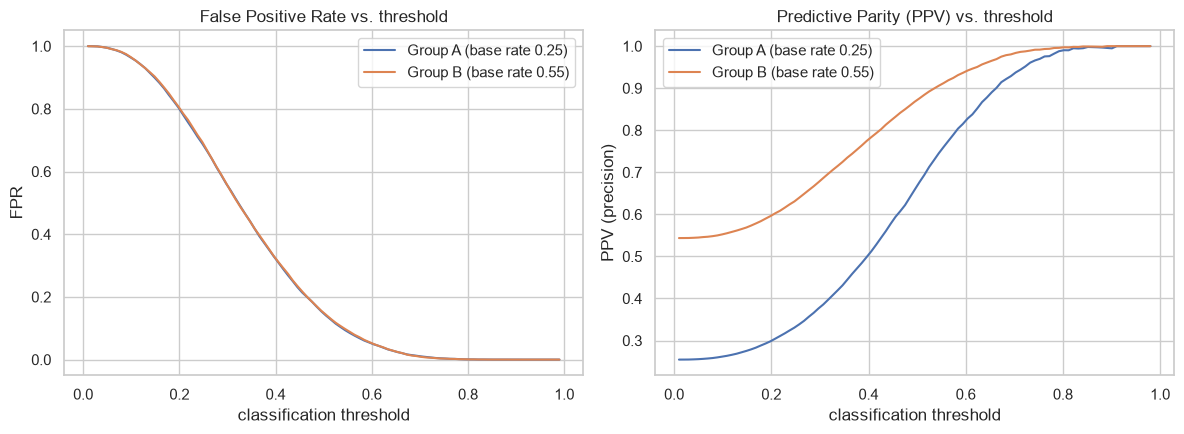

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
rng = np.random.default_rng(7)

# Synthetic illustration only (per this repo's convention: synthetic data is
# used here purely to isolate the impossibility-result mechanism from any
# real-world confound; the real analysis below uses COMPAS).
n = 20_000
base_rates = {"Group A (base rate 0.25)": 0.25, "Group B (base rate 0.55)": 0.55}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
thresholds = np.linspace(0.01, 0.99, 100)

for label, p in base_rates.items():
    y = rng.binomial(1, p, n)
    # risk score: correlated with y but noisy, same score-generating process for both groups
    score = np.clip(y * rng.beta(6, 3, n) + (1 - y) * rng.beta(3, 6, n), 0, 1)
    fprs, ppvs = [], []
    for t in thresholds:
        yhat = (score >= t).astype(int)
        tp = ((yhat == 1) & (y == 1)).sum()
        fp = ((yhat == 1) & (y == 0)).sum()
        fn = ((yhat == 0) & (y == 1)).sum()
        tn = ((yhat == 0) & (y == 0)).sum()
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        ppv = tp / (tp + fp) if (tp + fp) else np.nan
        fprs.append(fpr)
        ppvs.append(ppv)
    axes[0].plot(thresholds, fprs, label=label)
    axes[1].plot(thresholds, ppvs, label=label)

axes[0].set_title("False Positive Rate vs. threshold")
axes[0].set_xlabel("classification threshold")
axes[0].set_ylabel("FPR")
axes[1].set_title("Predictive Parity (PPV) vs. threshold")
axes[1].set_xlabel("classification threshold")
axes[1].set_ylabel("PPV (precision)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

Even though both groups' scores are generated by the *identical*
score-generating process (same noise model, same relationship between score
and true label), the group with the higher base rate has a strictly higher
FPR curve at every threshold that matches PPV between groups. There is no
single threshold — separate or shared — where both curves cross zero gap
*and* PPV is matched, unless the base rates are equal. This is the
impossibility result made visible: it's arithmetic, not a bias injected by
a "bad" model.

## 3. Implementation: measuring fairness on real COMPAS data

We now move to the real dataset. **COMPAS** (Correctional Offender
Management Profiling for Alternative Sanctions) is a risk-assessment tool
used by US courts to predict recidivism risk. ProPublica obtained COMPAS
scores for defendants in Broward County, FL and matched them against actual
two-year recidivism outcomes, then published the dataset alongside their
2016 investigation *Machine Bias*. We use their cleaned
`compas-scores-two-years.csv` file directly from ProPublica's public GitHub
repository.

In [2]:
COMPAS_URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis/"
    "master/compas-scores-two-years.csv"
)
raw = pd.read_csv(COMPAS_URL)
print(raw.shape)
raw[["race", "sex", "age", "priors_count", "decile_score", "two_year_recid"]].head()

(7214, 53)


,race,sex,age,priors_count,decile_score,two_year_recid
0,Other,Male,69,0,1,0
1,African-American,Male,34,0,3,1
2,African-American,Male,24,4,4,1
3,African-American,Male,23,1,8,0
4,Other,Male,43,2,1,0


We apply the same filtering ProPublica used in their own analysis
(removing rows with missing or inconsistent charge-date data, and cases
where the COMPAS screening date is more than 30 days from arrest, which
usually indicates linkage errors), and restrict the race comparison to
Black and White defendants — the comparison the original investigation and
the bulk of the follow-up academic literature centers on. This is a
narrowing of the dataset, not the population COMPAS is used on, and that
narrowing is itself worth flagging: any fairness analysis is only as
representative as the subgroup comparison it makes.

In [3]:
df = raw[
    (raw["days_b_screening_arrest"] <= 30)
    & (raw["days_b_screening_arrest"] >= -30)
    & (raw["is_recid"] != -1)
    & (raw["c_charge_degree"] != "O")
    & (raw["score_text"] != "N/A")
].copy()

df = df[df["race"].isin(["African-American", "Caucasian"])].copy()
df["race"] = df["race"].map({"African-American": "Black", "Caucasian": "White"})

# COMPAS's own binary "high risk" flag: decile score >= 5 is Medium/High
df["compas_high_risk"] = (df["decile_score"] >= 5).astype(int)

print(f"n = {len(df)}")
df.groupby("race")["two_year_recid"].mean().rename("base rate (actual 2yr recidivism)")

n = 5278


race
Black    0.52315
White    0.39087
Name: base rate (actual 2yr recidivism), dtype: float64

The two groups already have different base rates — this is exactly
the precondition for the impossibility result to bite. Now we compute all
four group fairness metrics on COMPAS's own `compas_high_risk` flag,
treating it as the classifier being audited, using `fairlearn`'s
`MetricFrame` for a clean group-wise breakdown.

In [4]:
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)
from sklearn.metrics import precision_score

y_true = df["two_year_recid"]
y_pred = df["compas_high_risk"]
sensitive = df["race"]

metrics = {
    "selection_rate (P(yhat=1))": selection_rate,
    "TPR (recall)": true_positive_rate,
    "FPR": false_positive_rate,
    "PPV (precision)": precision_score,
}
mf = MetricFrame(
    metrics=metrics, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive
)
mf.by_group

,selection_rate (P(yhat=1)),TPR (recall),FPR,PPV (precision)
race,,,,
Black,0.576063,0.715232,0.423382,0.649535
White,0.330956,0.503650,0.220141,0.594828


In [5]:
dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)

ppv_by_group = mf.by_group["PPV (precision)"]
ppv_diff = ppv_by_group.max() - ppv_by_group.min()

print(f"Demographic parity difference : {dp_diff:.3f}")
print(f"Equalized odds difference     : {eo_diff:.3f}  (max of TPR gap, FPR gap)")
print(f"Predictive parity (PPV) gap   : {ppv_diff:.3f}")

Demographic parity difference : 0.245
Equalized odds difference     : 0.212  (max of TPR gap, FPR gap)
Predictive parity (PPV) gap   : 0.055


This reproduces the substance of the original ProPublica finding:
COMPAS's FPR for Black defendants is substantially higher than for White
defendants (Black defendants who do *not* reoffend are much more likely to
be incorrectly flagged high-risk), while Northpointe's rebuttal was correct
that PPV (predictive parity) is comparatively close between groups. **Both
sides were citing true numbers — they were just citing different fairness
definitions**, and the impossibility result from Section 1.3 explains why
COMPAS could satisfy one and not the other simultaneously, given the base
rate gap we measured above.

Let's visualize the group-wise breakdown directly.

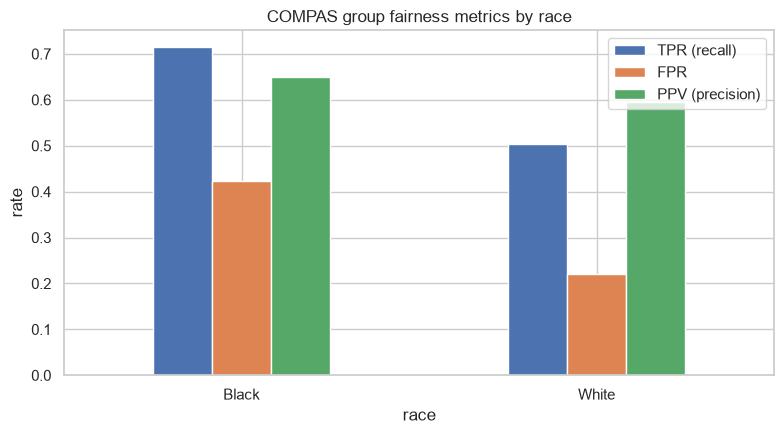

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
mf.by_group[["TPR (recall)", "FPR", "PPV (precision)"]].plot.bar(ax=ax, rot=0)
ax.set_ylabel("rate")
ax.set_title("COMPAS group fairness metrics by race")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 3.1 Individual fairness: a kNN consistency proxy

Group metrics say nothing about whether two similar defendants get similar
treatment. We approximate individual fairness with the consistency score
defined in Section 1.4, using a feature space of `age`, `priors_count`, and
`juv_fel_count` (excluding race, to test "fairness through unawareness" —
one specific, contested choice of similarity metric $d$, discussed further
below) with $k=15$ nearest neighbors.

In [7]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

feature_cols = ["age", "priors_count", "juv_fel_count", "juv_misd_count"]
X = StandardScaler().fit_transform(df[feature_cols])
yhat = df["compas_high_risk"].to_numpy()

k = 15
nn = NearestNeighbors(n_neighbors=k + 1).fit(X)
_, idx = nn.kneighbors(X)
neighbor_idx = idx[:, 1:]  # drop self

neighbor_mean_pred = yhat[neighbor_idx].mean(axis=1)
consistency_per_point = 1 - np.abs(yhat - neighbor_mean_pred)
consistency = consistency_per_point.mean()
print(f"Overall consistency score: {consistency:.3f}")

pd.Series(consistency_per_point, index=df.index).groupby(df["race"]).mean().rename(
    "mean per-individual consistency"
)

Overall consistency score: 0.676


race
Black    0.669837
White    0.684102
Name: mean per-individual consistency, dtype: float64

A consistency score this high means COMPAS's flags are locally
smooth in this feature space — individuals with similar age/priors profiles
mostly get the same flag, regardless of race, *when race is excluded from
the similarity metric*. This can look like a clean bill of health for
individual fairness — but it directly demonstrates the caveat from Section
1.4: this result depends entirely on excluding race from $d$. `priors_count`
and other features can still correlate with race through historical policing
patterns, so a high consistency score under this particular $d$ does not by
itself mean the model is free of racial disparity — it means the model is
locally consistent *with respect to a specific, contestable choice of what
counts as "similar."*

## 4. Use cases

- **Criminal justice risk assessment** (COMPAS, PSA, and similar tools) —
  courts use these scores for bail, sentencing, and parole decisions. The
  choice between equalized odds and predictive parity has direct liberty
  consequences, which is why the COMPAS debate became the field's
  founding case study.
- **Lending and credit underwriting** — regulators (e.g. under the US
  Equal Credit Opportunity Act) often evaluate demographic parity in
  approval *rates* as a first-pass disparate-impact screen, even when the
  underlying model targets predictive accuracy.
- **Hiring/resume screening** — demographic parity in interview/callback
  rates is a common audit metric (e.g. NYC Local Law 144 requires bias
  audits of automated hiring tools), while equal opportunity is often the
  more defensible target if the true outcome (job performance) has a
  well-defined ground truth.
- **Individual fairness in recommender/pricing systems** — e.g. two
  customers with near-identical purchase histories receiving very
  different prices or offers is often audited via a consistency-style
  metric even without an explicit protected group, since it's a complaint
  users make personally ("why did *I* get a worse deal"), not as a group.

## 5. Limitations & debates

- **The impossibility result is not a modeling bug you can fix with a
  better algorithm.** When group base rates differ, no classifier —
  however well-trained — satisfies predictive parity and equalized odds
  simultaneously (Section 1.3). Any claim that a new model "solves"
  fairness by satisfying all metrics at once should be treated with strong
  skepticism unless base rates are equal or the classifier is perfect.
- **Choosing a metric is a policy decision, not a technical one.**
  Equalized odds prioritizes equal error *rates*; predictive parity
  prioritizes equal *meaning* of a given score. Which one matters more
  depends on what's at stake for a false positive vs. a false negative in
  that specific deployment (e.g. wrongly denying parole vs. wrongly
  granting it) — this is a normative question fairness metrics cannot
  answer on their own.
- **"Fairness through unawareness" (dropping the protected attribute) does
  not guarantee any fairness property**, group or individual — proxy
  variables (zip code, priors count, name) frequently reconstruct the
  protected attribute's information. Our individual-fairness computation
  above is a direct illustration: excluding race from $d$ does not verify
  the model is unaffected by race's correlates.
- **Individual fairness pushes the hardest question — what does "similar"
  mean? — into the design of the similarity metric $d$**, which is rarely
  specified formally in practice and is itself a value-laden choice. A kNN
  consistency proxy (as used here) is a convenience, not a validated
  measurement of Dwork et al.'s original Lipschitz condition; it inherits
  every bias baked into the chosen feature space and distance function.
- **Group fairness metrics computed on a single train/test split, as done
  here, are point estimates.** Especially for smaller subgroups, confidence
  intervals matter — a gap that looks large can be within noise. Production
  fairness audits should bootstrap or otherwise quantify uncertainty around
  each metric, not just report a point value as this tutorial does for
  clarity.
- **Multi-group and intersectional fairness (e.g. Black women specifically,
  not "Black" and "women" separately) is not covered by any of the binary
  two-group definitions above**, and is an active, harder research area
  (subgroup fairness / gerrymandering fairness) — checking parity for each
  attribute independently does not guarantee parity for their intersection.

## References

- Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012).
  *Fairness Through Awareness*. ITCS.
- Hardt, M., Price, E., & Srebro, N. (2016). *Equality of Opportunity in
  Supervised Learning*. NeurIPS.
- Chouldechova, A. (2017). *Fair Prediction with Disparate Impact: A Study
  of Bias in Recidivism Prediction Instruments*. Big Data, 5(2).
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2016). *Inherent
  Trade-Offs in the Fair Determination of Risk Scores*. ITCS 2017 /
  arXiv:1609.05807.
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine
  Learning: Limitations and Opportunities*. fairmlbook.org.
- Angwin, J., Larson, J., Mattu, S., & Kirchner, L. (2016). *Machine Bias*.
  ProPublica.
- [ProPublica compas-analysis dataset & methodology](https://github.com/propublica/compas-analysis)
- [Fairlearn documentation](https://fairlearn.org)